<a href="https://colab.research.google.com/github/Mugetsu-Nuckie/dzstatprac/blob/main/cs2_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Датасет по CS2 матчам на про сцене (развед анализ)

| Файл | Строк | Столбцов | Описание |
|------|-------|----------|----------|
| `cs2_all_tiers_games.csv` | 19 031 | 98 | Все матчи (Tier 1 + 2 + 3), детальная статистика 10 игроков |
| `cs2_tier1_games.csv` | 10 274 | 98 | Матчи Tier 1 |
| `cs2_tier2_games.csv` | 7 743 | 98 | Матчи Tier 2 |
| `cs2_tier3_games.csv` | 1 014 | 98 | Матчи Tier 3 |
| `players.csv` | 2 443 | 2 | Справочник игроков (id, name) |
| `teams.csv` | 18 402 | 2 | Справочник команд (id, name) |
| `tournaments.csv` | 320 | 1 | Список турниров |

### Ключевые столбцы основной таблицы

| Группа | Столбцы | Описание |
|--------|---------|----------|
| Идентификаторы | `match_id`, `game_id`, `tournament` | Матч, карта, турнир |
| Команды | `team1`, `team2`, `team1_id`, `team2_id` | Названия и ID команд |
| Счёт матча | `score1_match`, `score2_match` | Счёт по картам в матче (например, 2:1) |
| Счёт карты | `score1_game`, `score2_game` | Счёт в раундах на карте (например, 13:7) |
| Метаданные | `bestOf`, `map_name`, `datetime`, `is_total` | Формат, карта, дата, флаг агрегации |
| Целевая переменная | `team1_win` | 1, если team1 победила на карте |
| Статистика игроков | `team{1,2}_player{1-5}_{kills,deaths,assists,adr,kast,kddiff}` | 6 метрик на 10 игроков = 60 столбцов |

 строки с `is_total=True`  - общие записи матчей. Строки с `is_total=False`  - результаты отдельных карт с полной игровой статистикой. Для анализа на уровне карт используются только записи с `is_total=False`.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')


DATA_DIR = '/data/'

games = pd.read_csv(DATA_DIR + 'cs2_all_tiers_games.csv', index_col=0)
games_t1 = pd.read_csv(DATA_DIR + 'cs2_tier1_games.csv', index_col=0)
games_t2 = pd.read_csv(DATA_DIR + 'cs2_tier2_games.csv', index_col=0)
games_t3 = pd.read_csv(DATA_DIR + 'cs2_tier3_games.csv', index_col=0)
players = pd.read_csv(DATA_DIR + 'players.csv')
teams_ref = pd.read_csv(DATA_DIR + 'teams.csv', index_col=0)
tournaments_ref = pd.read_csv(DATA_DIR + 'tournaments.csv', index_col=0)

games['datetime'] = pd.to_datetime(games['datetime'], errors='coerce')
games = games.drop_duplicates()


maps_df = games[games['is_total'] == False].copy()

matches = games.drop_duplicates(subset='match_id')[
    [
        'match_id', 'tournament', 'team1', 'team2', 'team1_id', 'team2_id',
        'score1_match', 'score2_match', 'bestOf', 'datetime', 'games_played'
    ]
].copy()

matches['team1_won'] = (matches['score1_match'] > matches['score2_match']).astype(int)


t1_ids = set(games_t1['match_id'].unique())
t2_ids = set(games_t2['match_id'].unique())
t3_ids = set(games_t3['match_id'].unique())

def get_tier(mid):
    if mid in t1_ids:
        return 'Tier 1'
    elif mid in t2_ids:
        return 'Tier 2'
    elif mid in t3_ids:
        return 'Tier 3'
    else:
        return 'Unknown'

matches['tier'] = matches['match_id'].apply(get_tier)
maps_df['tier'] = maps_df['match_id'].apply(get_tier)

print(f"Загружено: {len(games)} строк, {len(games.columns)} столбцов")
print(f"Карт: {len(maps_df)}, Матчей: {len(matches)}")
print(f"Период: {games['datetime'].min()} — {games['datetime'].max()}")

Загружено: 19025 строк, 98 столбцов
Карт: 9824, Матчей: 9201
Период: 2023-01-10 09:30:00 — 2026-04-03 17:00:00


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


---
## 1. Динамика матчей по времени

Датасет охватывает примерно 3 года и 3 месяца профессионального CS2. Количество матчей в целом стабильно, с пиками в месяцы проведения крупных турниров.

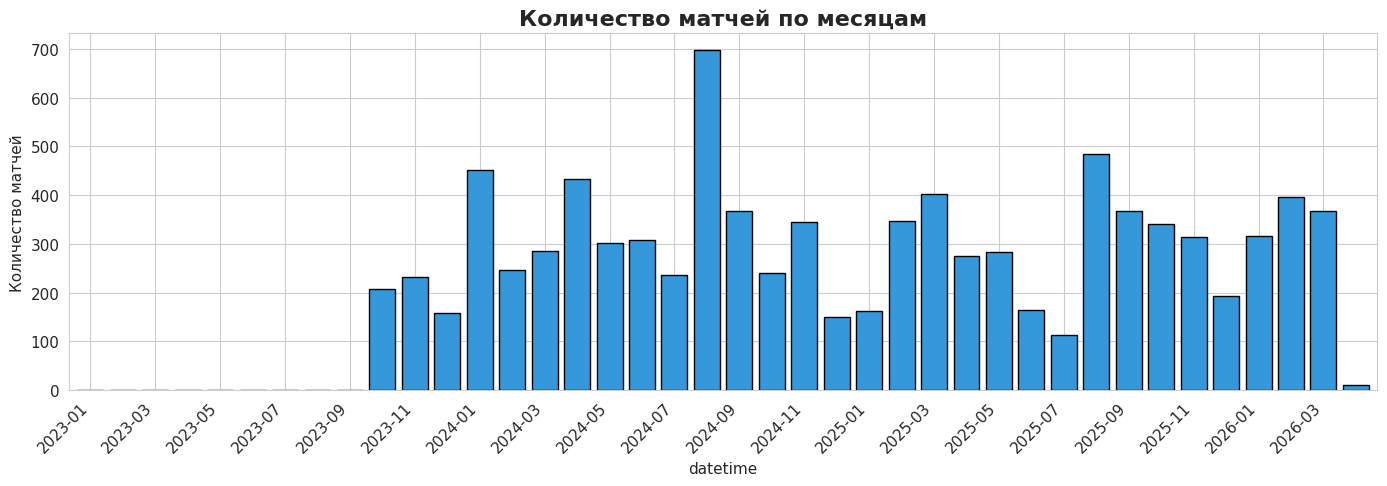

In [6]:
fig, ax = plt.subplots(figsize=(14, 5))

monthly = matches.set_index('datetime').resample('ME').size()

monthly.plot( kind='bar', ax=ax, color='#3498db',edgecolor='black',width=0.8)

ax.set_title('Количество матчей по месяцам', fontsize=16, fontweight='bold')
ax.set_ylabel('Количество матчей')

labels = [d.strftime('%Y-%m') for d in monthly.index]
step = max(1, len(labels) // 15)

ax.set_xticks(range(0, len(labels), step))
ax.set_xticklabels(labels[::step], rotation=45, ha='right')

plt.tight_layout()
plt.show()

---
## 2. Распределение по тирам

Tier 2 - 4 418 матчей (48.0%), Tier 1 - 4 110 матчей (44.7%), Tier 3 - 673 матча (7.3%). Основу датасета составляют два верхних тира.

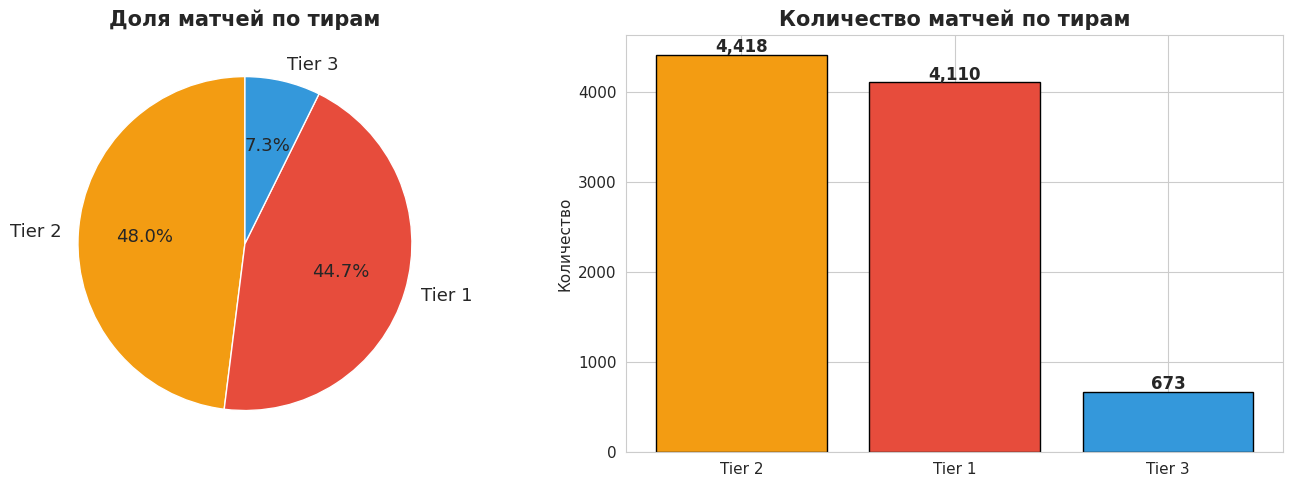

In [7]:
tier_counts = matches['tier'].value_counts()
colors_t = {'Tier 1': '#e74c3c','Tier 2': '#f39c12','Tier 3': '#3498db','Unknown': '#95a5a6'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].pie( tier_counts.values, labels=tier_counts.index, autopct='%1.1f%%',colors=[colors_t[t] for t in tier_counts.index],startangle=90,textprops={'fontsize': 13})

axes[0].set_title('Доля матчей по тирам', fontsize=15, fontweight='bold')

axes[1].bar(tier_counts.index, tier_counts.values,color=[colors_t[t] for t in tier_counts.index],edgecolor='black')

axes[1].set_title('Количество матчей по тирам', fontsize=15, fontweight='bold')
axes[1].set_ylabel('Количество')

for i, (k, v) in enumerate(tier_counts.items()):
    axes[1].text(i, v + 30, f'{v:,}', ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

---
## 3. Топ-20 команд по количеству сыгранных карт

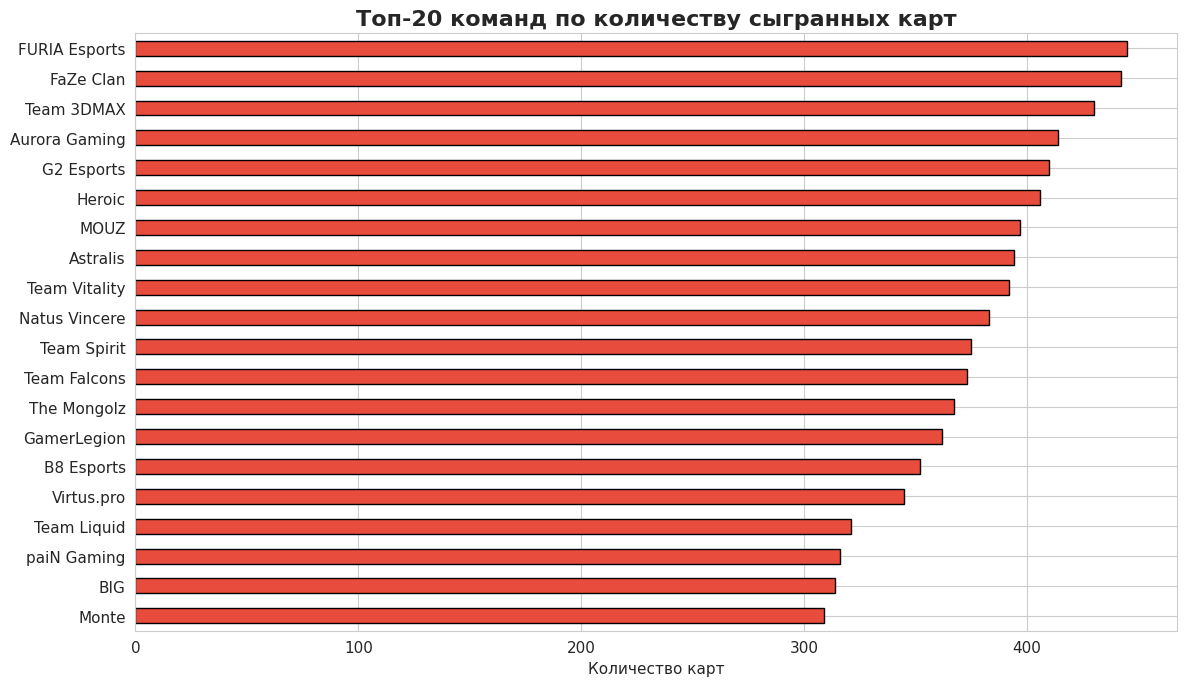

In [8]:
all_teams_series = pd.concat([maps_df['team1'], maps_df['team2']]).dropna()
top20 = all_teams_series.value_counts().head(20)

fig, ax = plt.subplots(figsize=(12, 7))

top20.plot( kind='barh', ax=ax, color='#e74c3c', edgecolor='black')

ax.set_title('Топ-20 команд по количеству сыгранных карт', fontsize=16, fontweight='bold')
ax.set_xlabel('Количество карт')
ax.invert_yaxis()

plt.tight_layout()
plt.show()

---
## 4. Популярность карт

Наиболее играемые карты: Ancient (1 714), Mirage (1 620), Nuke (1 416), Inferno (1 272), Anubis (1 178), Dust2 (1 151). Карты Vertigo, Overpass и Train менее популярны.

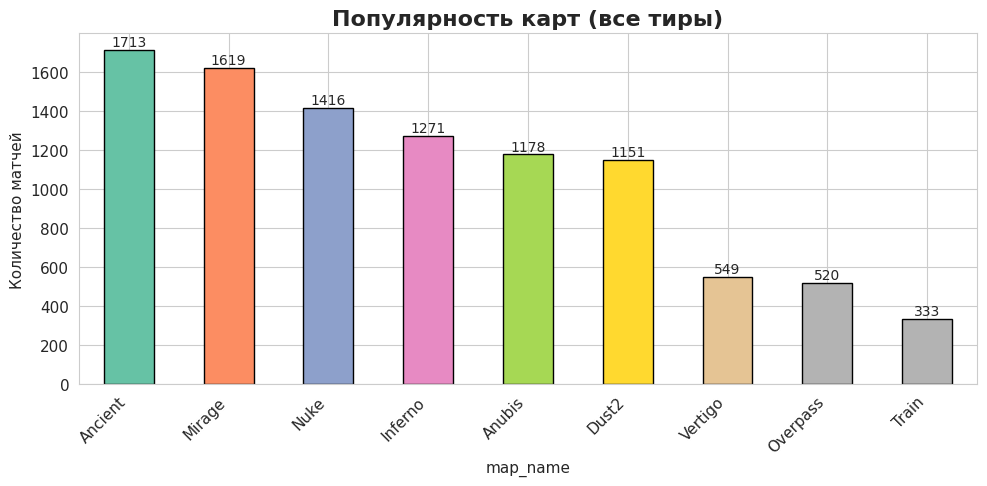

In [9]:
map_counts = maps_df['map_name'].value_counts()

fig, ax = plt.subplots(figsize=(10, 5))

map_counts.plot(kind='bar',ax=ax,color=plt.cm.Set2(np.linspace(0, 1, len(map_counts))),edgecolor='black')

ax.set_title('Популярность карт (все тиры)', fontsize=16, fontweight='bold')
ax.set_ylabel('Количество матчей')

for i, v in enumerate(map_counts.values):
    ax.text(i, v + 20, str(v), ha='center', fontsize=10)

plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

##5. Самые частые счета

Типичные финальные счета: 13:7, 13:11, 13:9, 13:10.

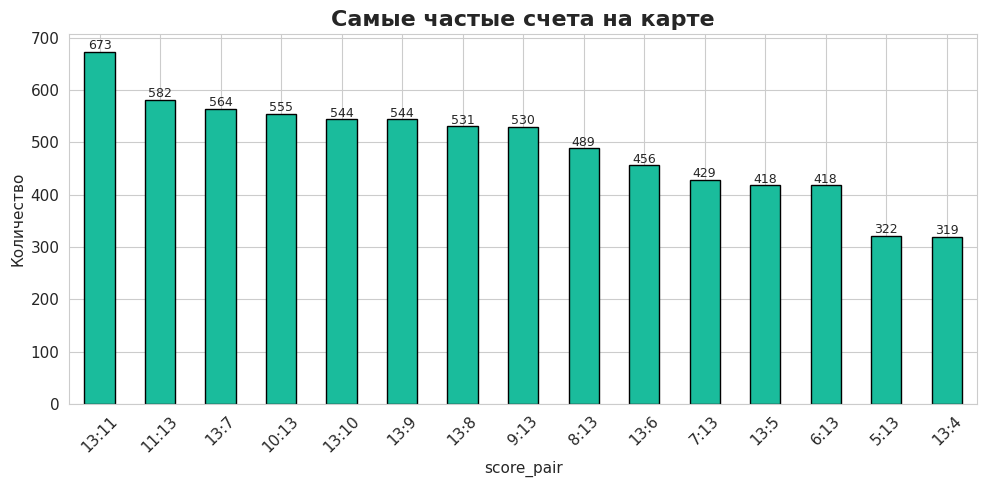

In [12]:
valid_maps = maps_df.dropna(subset=['score1_game', 'score2_game'])
valid_maps_copy = valid_maps.copy()

valid_maps_copy['score_pair'] = (
    valid_maps_copy['score1_game'].astype(int).astype(str) + ':' +
    valid_maps_copy['score2_game'].astype(int).astype(str)
)

top_scores = valid_maps_copy['score_pair'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(10, 5))

top_scores.plot( kind='bar', ax=ax,color='#1abc9c',edgecolor='black')

ax.set_title('Самые частые счета на карте', fontsize=16, fontweight='bold')
ax.set_ylabel('Количество')

for i, v in enumerate(top_scores.values):
    ax.text(i, v + 5, str(v), ha='center', fontsize=9)

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

---
## 6. Формат матчей

Самый популярный формат bo3 (7 273). Bo1 - 1 734 (отборы,квалы) , bo5 - 79 (финалы крупных турниров).

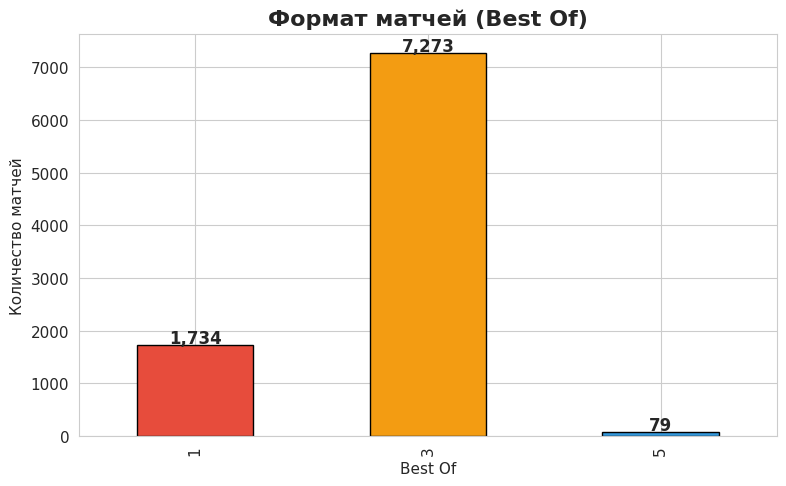

In [13]:
fig, ax = plt.subplots(figsize=(8, 5))
bo = matches['bestOf'].dropna().astype(int).value_counts().sort_index()
bo.plot(kind='bar', ax=ax, color=['#e74c3c', '#f39c12', '#3498db'][:len(bo)], edgecolor='black')
ax.set_title('Формат матчей (Best Of)', fontsize=16, fontweight='bold')
ax.set_ylabel('Количество матчей')
ax.set_xlabel('Best Of')
for i, v in enumerate(bo.values):
    ax.text(i, v + 30, f'{v:,}', ha='center', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 7. Распределение статистики игроков

По каждой карте доступно 6 метрик для каждого из 10 игроков:

Метрика_Описание_Среднее_Std

kills_Убийства_19.5_11.7

deaths_Смерти_19.6_10.9

assists_Ассисты_6.8_4.7

adr_Average Damage per Round_72.9_18.0

kast_% раундов с Kill/Assist/Survived/Traded_71.7_11.2

kddiff_Разница Kill − Death_~0_7.2_

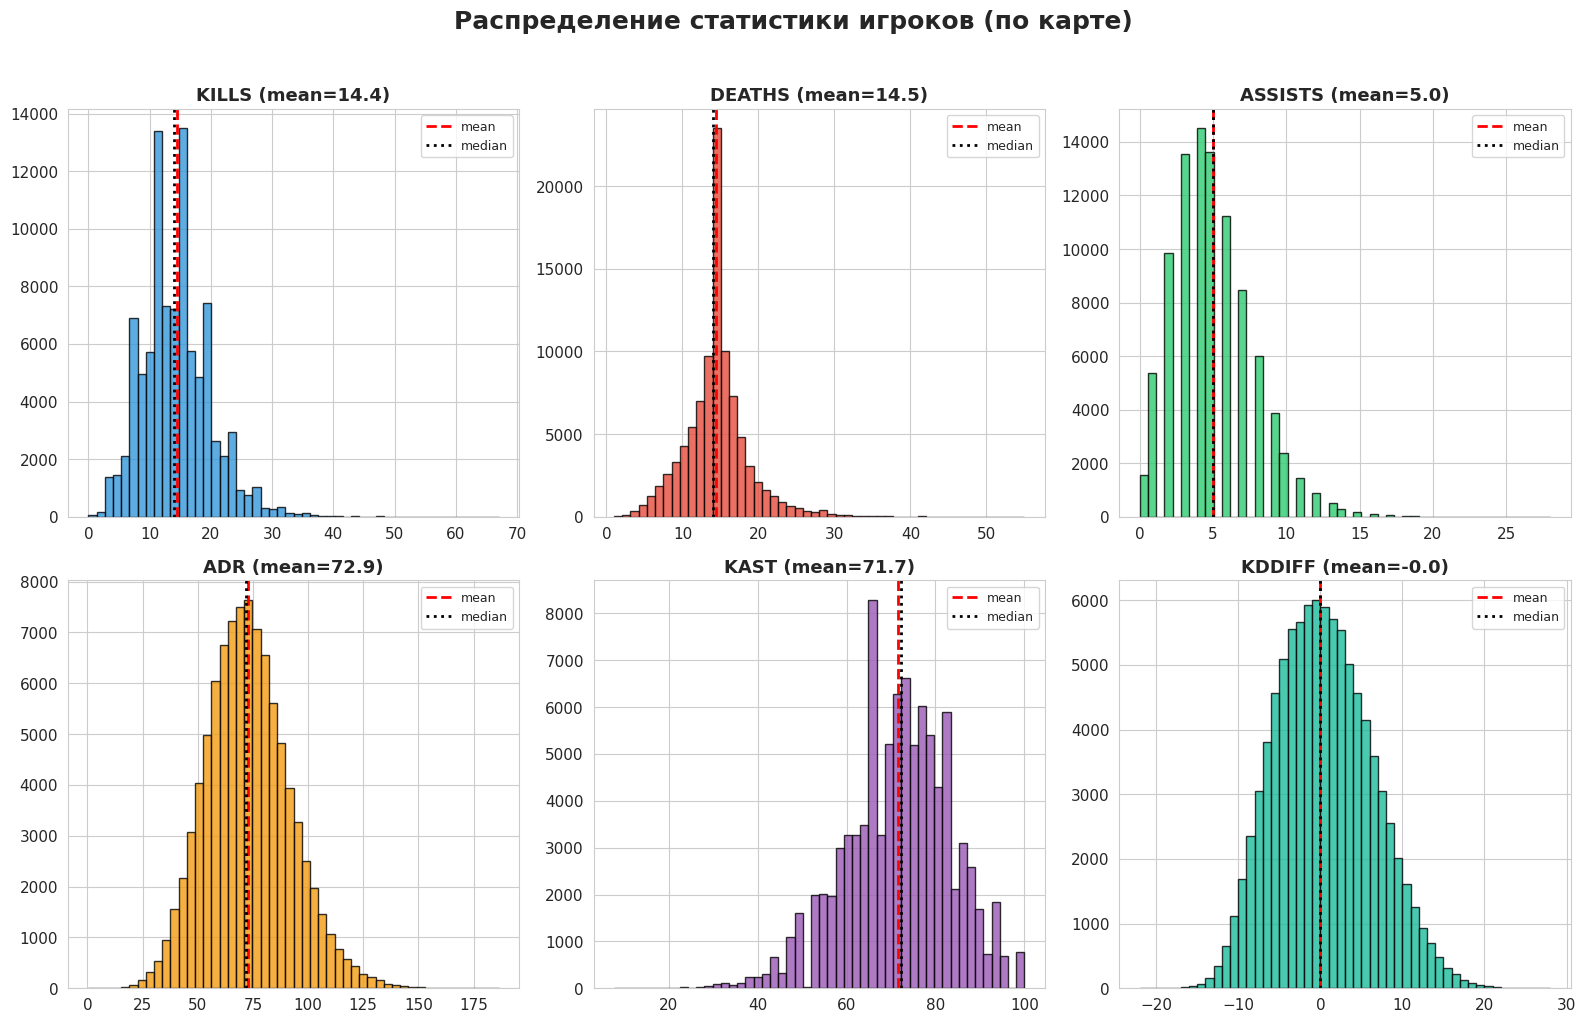

In [15]:
stat_suffixes = ['kills', 'deaths', 'assists', 'adr', 'kast', 'kddiff']
stat_data = {}
for s in stat_suffixes:
    cols = [c for c in maps_df.columns if c.endswith('_' + s)]
    vals = maps_df[cols].values.flatten()
    vals = vals[~np.isnan(vals)]
    stat_data[s] = vals

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c']

for i, (name, vals) in enumerate(stat_data.items()):
    axes[i].hist(vals, bins=50, color=colors[i], edgecolor='black', alpha=0.8)
    axes[i].set_title(f'{name.upper()} (mean={vals.mean():.1f})', fontsize=13, fontweight='bold')
    axes[i].axvline(vals.mean(), color='red', linestyle='--', linewidth=2, label='mean')
    axes[i].axvline(np.median(vals), color='black', linestyle=':', linewidth=2, label='median')
    axes[i].legend(fontsize=9)

plt.suptitle('Распределение статистики игроков (по карте)', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 8. Выбросы

Выбросы наблюдаются в kills (до 110), deaths (до 96), ADR (до 186.4). Вероятная причина - матчи с допами.

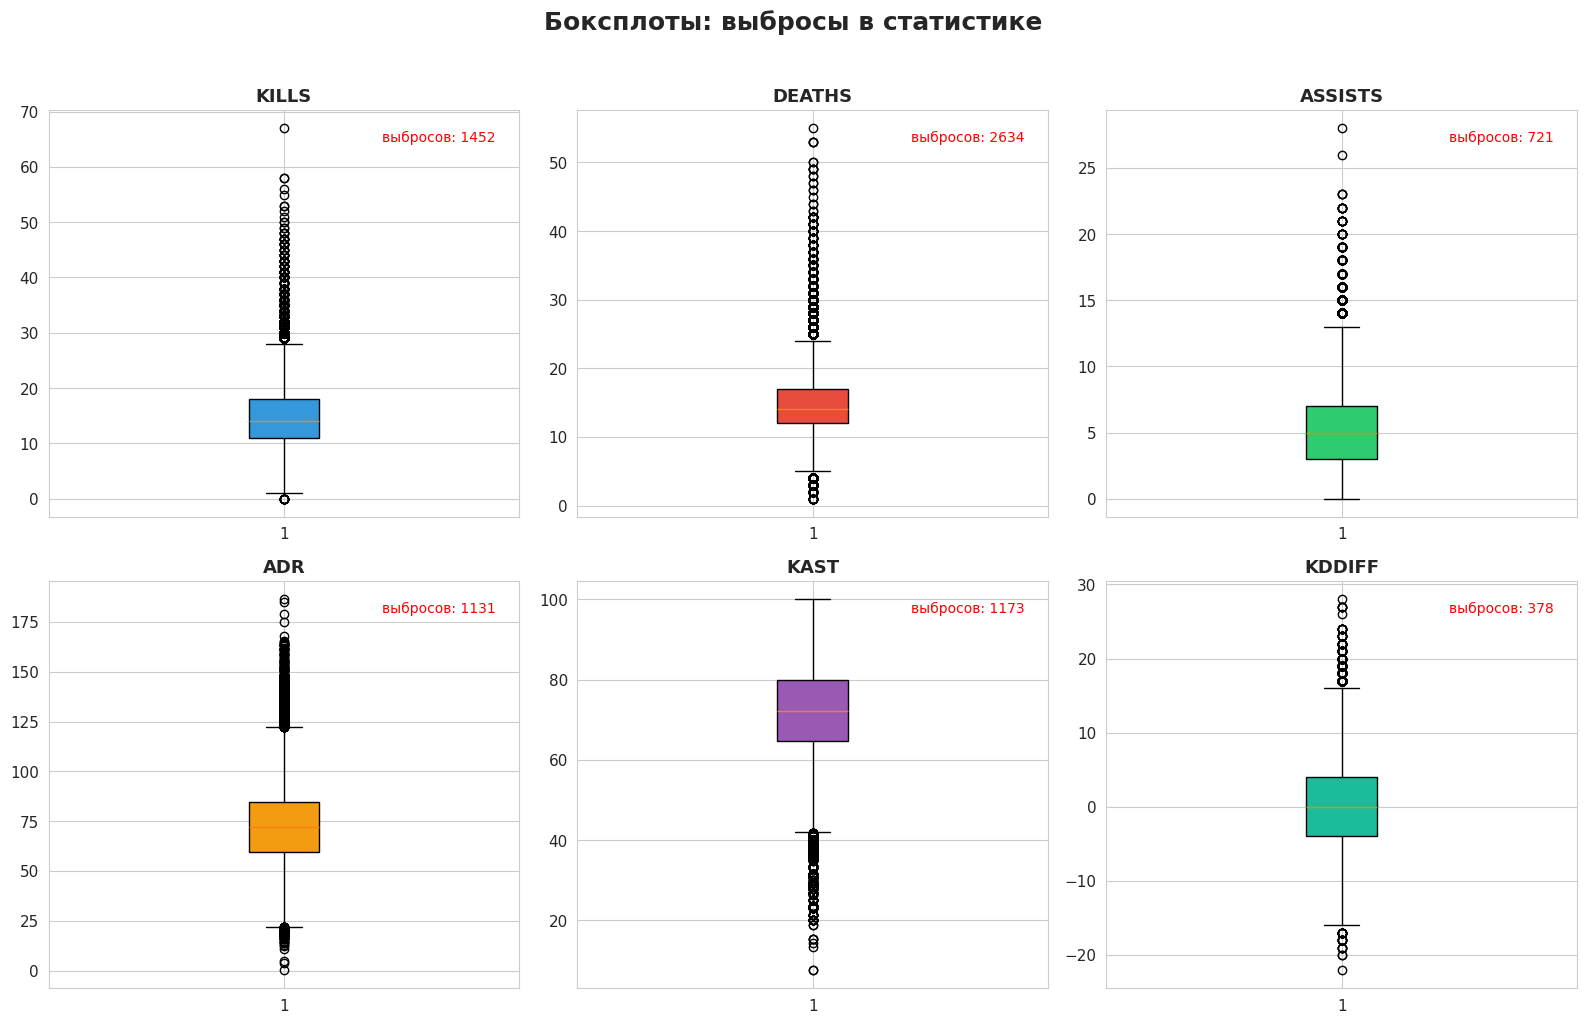

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, (name, vals) in enumerate(stat_data.items()):
    bp = axes[i].boxplot(vals, vert=True, patch_artist=True)
    bp['boxes'][0].set_facecolor(colors[i])
    axes[i].set_title(name.upper(), fontsize=13, fontweight='bold')
    q1, q3 = np.percentile(vals, [25, 75])
    iqr = q3 - q1
    outliers = ((vals < q1 - 1.5*iqr) | (vals > q3 + 1.5*iqr)).sum()
    axes[i].text(0.95, 0.95, f'выбросов: {outliers}', transform=axes[i].transAxes,
                ha='right', va='top', fontsize=10, color='red')

plt.suptitle('Боксплоты: выбросы в статистике', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 9. Корреляционная матрица

Основные наблюдения:

- ADR и kills: r = 0.69 - больше урона соответствует большему числу убийств.
- KAST и победа: r = 0.52 - стабильность игрока связана с результатом команды.
- KDDiff и победа: r = 0.50 - превосходство по разнице убийств/смертей связано с победой.
- Deaths и score_opp: r = 0.81 - чем больше раундов выигрывает противник, тем больше смертей у игрока.
- Score_team и победа: r = 0.69 (очев), score_opp и победа: r = −0.68.

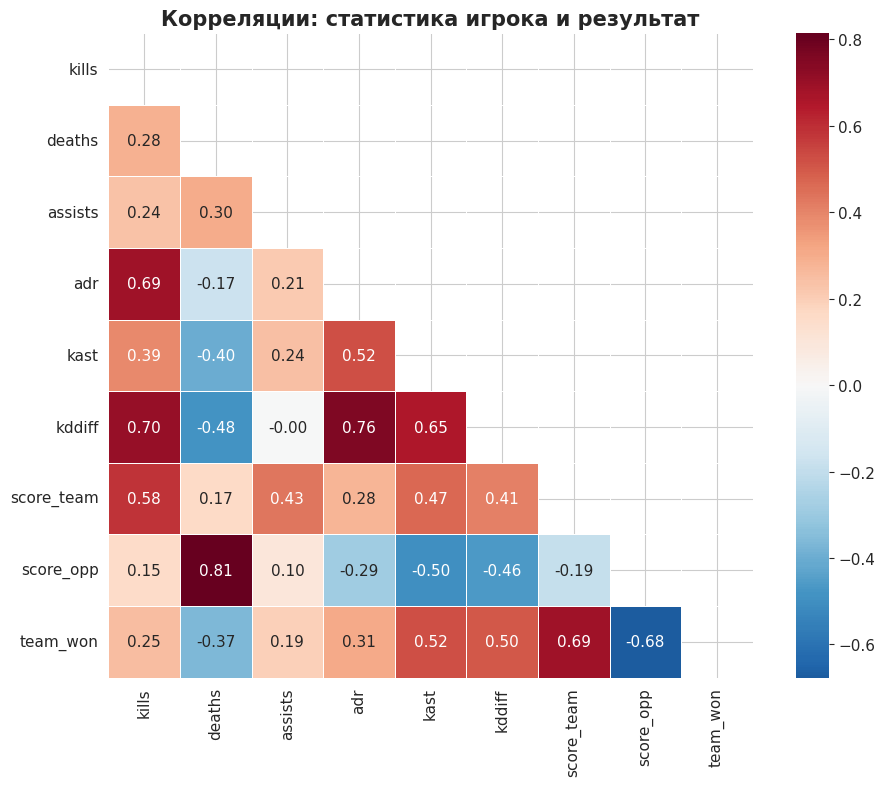

In [17]:
sample_cols = ['team1_player1_kills', 'team1_player1_deaths', 'team1_player1_assists',
               'team1_player1_adr', 'team1_player1_kast', 'team1_player1_kddiff',
               'score1_game', 'score2_game', 'team1_win']
sample = maps_df[sample_cols].dropna()
sample.columns = ['kills', 'deaths', 'assists', 'adr', 'kast', 'kddiff', 'score_team', 'score_opp', 'team_won']

fig, ax = plt.subplots(figsize=(10, 8))
corr = sample.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            ax=ax, square=True, linewidths=0.5)
ax.set_title('Корреляции: статистика игрока и результат', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 10. Winrate team1 по картам

Team1 побеждает на большинстве карт несколько чаще 50%. Это связано с тем, что team один выигрывает в подбросе монетки

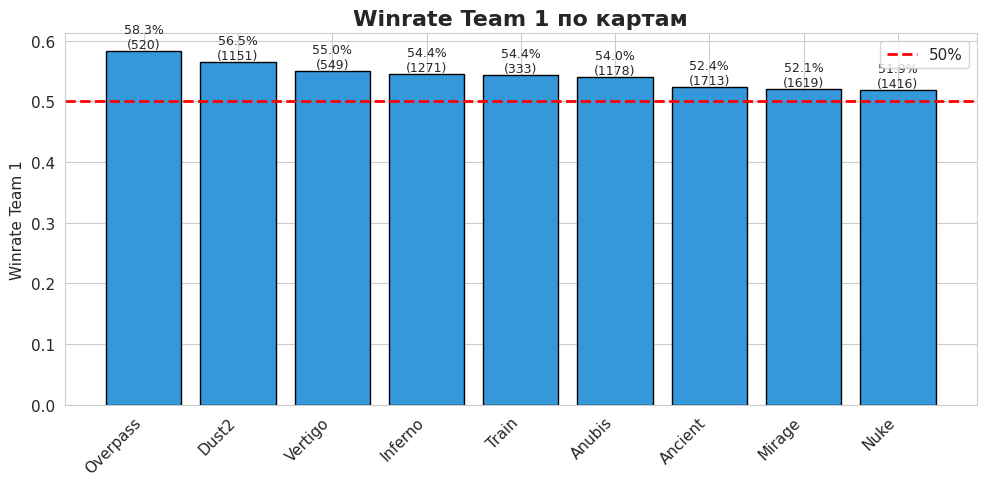

In [18]:
wr = maps_df.groupby('map_name')['team1_win'].agg(['mean', 'count']).sort_values('mean', ascending=False)
wr.columns = ['winrate', 'games']

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(wr.index, wr['winrate'], color='#3498db', edgecolor='black')
ax.axhline(0.5, color='red', linestyle='--', linewidth=2, label='50%')
ax.set_title('Winrate Team 1 по картам', fontsize=16, fontweight='bold')
ax.set_ylabel('Winrate Team 1')
for bar, (_, row) in zip(bars, wr.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{row["winrate"]:.1%}\n({int(row["games"])})', ha='center', fontsize=9)
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

---
## 11. Средний ADR: победители и проигравшие

Распределения наглядно разделены. Средний командный ADR победителей - около 80, проигравших - около 66.

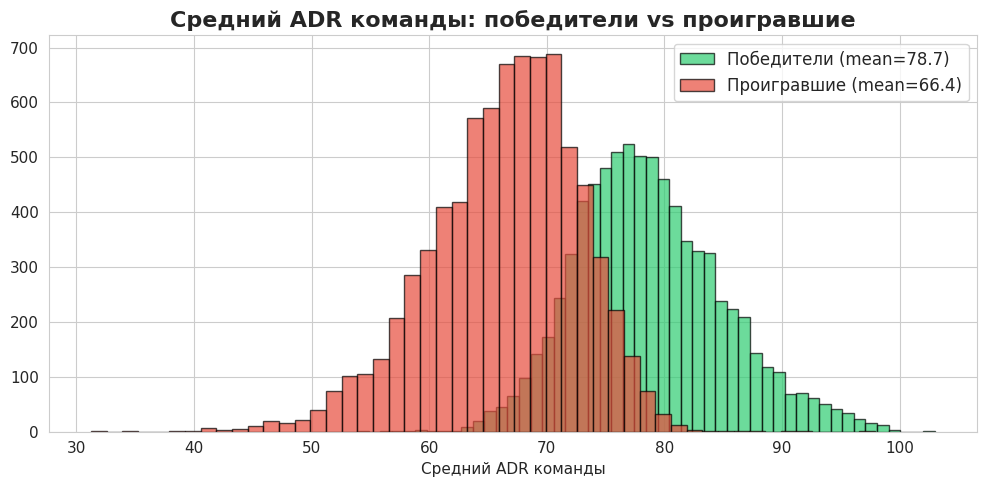

In [19]:
adr_cols_t1 = [f'team1_player{i}_adr' for i in range(1, 6)]
adr_cols_t2 = [f'team2_player{i}_adr' for i in range(1, 6)]
valid = maps_df.dropna(subset=adr_cols_t1 + adr_cols_t2 + ['team1_win']).copy()
valid['adr_team1'] = valid[adr_cols_t1].mean(axis=1)
valid['adr_team2'] = valid[adr_cols_t2].mean(axis=1)
valid['adr_winner'] = np.where(valid['team1_win'] == 1, valid['adr_team1'], valid['adr_team2'])
valid['adr_loser'] = np.where(valid['team1_win'] == 1, valid['adr_team2'], valid['adr_team1'])

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(valid['adr_winner'], bins=50, alpha=0.7, color='#2ecc71', edgecolor='black',
        label=f'Победители (mean={valid["adr_winner"].mean():.1f})')
ax.hist(valid['adr_loser'], bins=50, alpha=0.7, color='#e74c3c', edgecolor='black',
        label=f'Проигравшие (mean={valid["adr_loser"].mean():.1f})')
ax.set_title('Средний ADR команды: победители vs проигравшие', fontsize=16, fontweight='bold')
ax.set_xlabel('Средний ADR команды')
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()

---
## 12. Топ-15 турниров по числу матчей

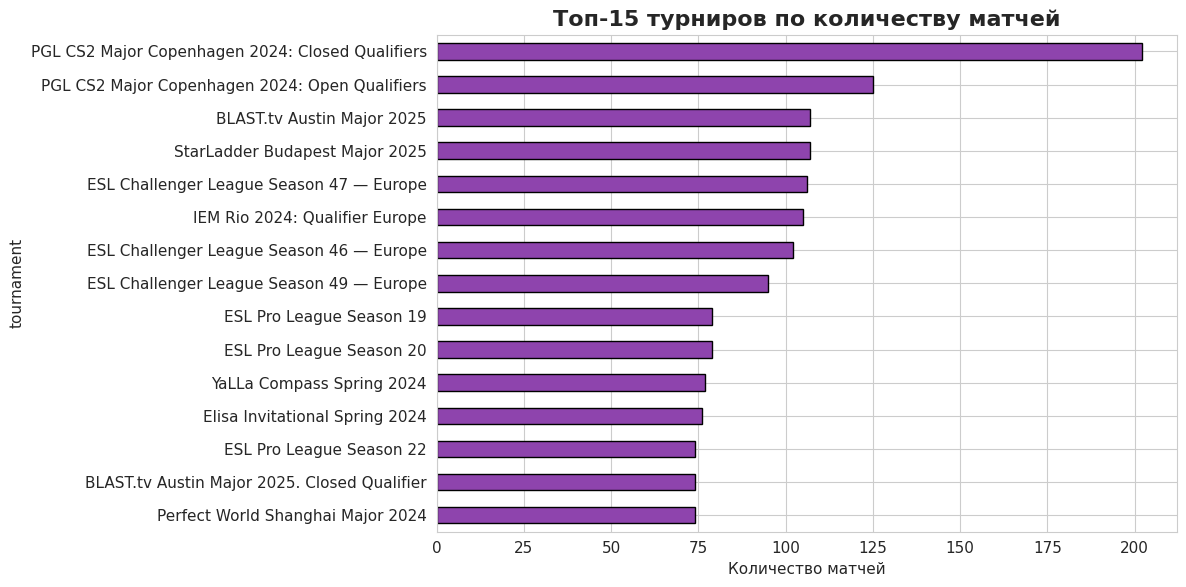

In [20]:
tourn_counts = matches['tournament'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(12, 6))
tourn_counts.plot(kind='barh', ax=ax, color='#8e44ad', edgecolor='black')
ax.set_title('Топ-15 турниров по количеству матчей', fontsize=16, fontweight='bold')
ax.set_xlabel('Количество матчей')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

---
## 14. Пропуски в данных

На уровне отдельных карт пропуски минимальны. Качество данных высокое.

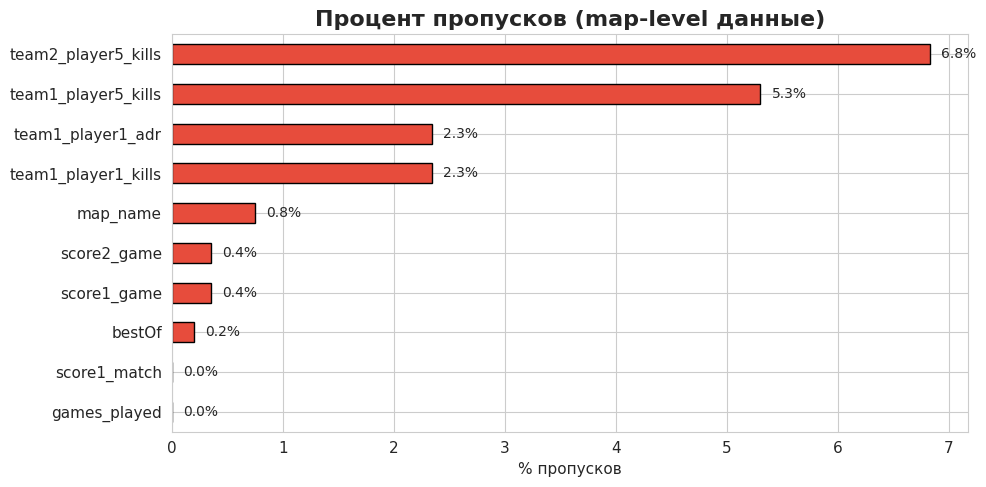

In [21]:
cols_check = ['score1_game', 'score2_game', 'map_name',
              'team1_player1_kills', 'team1_player1_adr',
              'team1_player5_kills', 'team2_player5_kills',
              'bestOf', 'score1_match', 'games_played']
miss_pct = maps_df[cols_check].isnull().mean() * 100

fig, ax = plt.subplots(figsize=(10, 5))
miss_pct.sort_values(ascending=True).plot(kind='barh', ax=ax, color='#e74c3c', edgecolor='black')
ax.set_title('Процент пропусков (map-level данные)', fontsize=16, fontweight='bold')
ax.set_xlabel('% пропусков')
for i, v in enumerate(miss_pct.sort_values(ascending=True).values):
    ax.text(v + 0.1, i, f'{v:.1f}%', va='center', fontsize=10)
plt.tight_layout()
plt.show()

---
## 15. Попарные зависимости

На графике видно разделение классов по ADR, kills и KAST. Победители систематически демонстрируют лучшую статистику по всем метрикам.

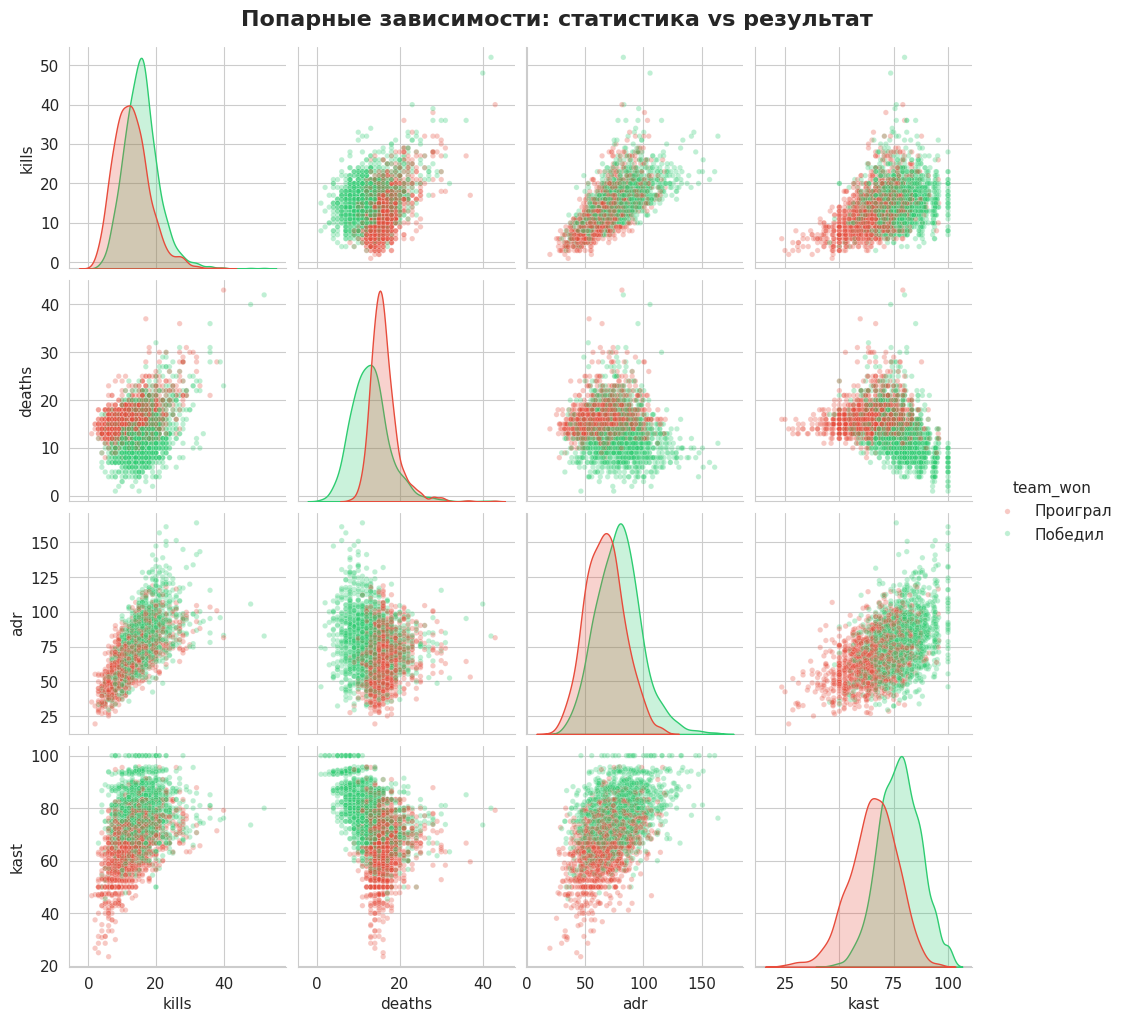

In [22]:
pair_data = sample[['kills', 'deaths', 'adr', 'kast', 'team_won']].sample(min(3000, len(sample)), random_state=42)
pair_data['team_won'] = pair_data['team_won'].map({0: 'Проиграл', 1: 'Победил'})
g = sns.pairplot(pair_data, hue='team_won', diag_kind='kde',
                 palette={'Победил': '#2ecc71', 'Проиграл': '#e74c3c'},
                 plot_kws={'alpha': 0.3, 's': 15})
g.figure.suptitle('Попарные зависимости: статистика vs результат', y=1.02, fontsize=16, fontweight='bold')
plt.show()

---
---

#  Какие задачи я хочу рассмотреть

## Задача 1. Предсказание победителя карты

- **Параметры:** карта, исторический winrate команд на данной карте, средние показатели игроков за последние N карт, история личных встреч, рейтинг HLTV
- **Где применяется:** аналитика ставок, тактическая подготовка

## Задача 2. Предсказание счёта карты

- **Параметры:** аналогичные задаче 1 + формат матча (bo1, bo3, bo5), тир турнира
- **Где применяется:** прогнозирование тоталов и фор

## Задача 3. Предсказание индивидуальной статистики игрока

- **Параметры:** карта, команда, противник, средняя статистика за последние N карт
- **Где применяется:** Ставка на тотал киллов, скаутинг, принятие решений по составу

## Задача 4. Предсказание исхода матча

- **Параметры:** команды, формат, турнир, общая статистика
- **Где применяется:** прогнозирование серий, аналитика турниров

## Задача 5. Кластеризация команд и игроков по стилю

- **Подход:** обобщение статистики команд/игроков, применение K-Means/DBSCAN, визуализация.
- **Где применяется:** выявление игровых стилей, формирование составов, поиск перспективных игроков в Tier 2–3
